In [112]:
%pip install pandas


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [113]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Business Problem Understanding or  Project Understanding

- predict whether the customer is eligible for the loan or not

In [114]:
import numpy as np
import pandas as pd

import warnings
warnings.simplefilter("ignore")

# Extract

- Extract the raw data
- Data Understanding
    - Understanding meaning of each column name very clearly
- Data Exploration
    - Observe the internal data
    - Ovserve the values in each column
    - Checking unique values of each column
- Exploratory Data Analysis (EDA) : observing the entire raw data
    - observing the raw data
    - other than unique...  what are remaining check on raw data

**extract raw data**

In [115]:
df = pd.read_csv("LoanData.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Data Understanding**
- Unserstand meaning of each & every column name very clearly

**Data Exploration**
- Exploring the given raw data

In [116]:
df.shape

(614, 13)

- in the given dataset, it has 614 records with 13 columns

In [117]:
df.columns.tolist()

['Loan_ID',
 'Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'Loan_Status']

- all column names are as per syntax, no need to rename

In [118]:
df['Loan_ID'].unique()

<StringArray>
['LP001002', 'LP001003', 'LP001005', 'LP001006', 'LP001008', 'LP001011',
 'LP001013', 'LP001014', 'LP001018', 'LP001020',
 ...
 'LP002959', 'LP002960', 'LP002961', 'LP002964', 'LP002974', 'LP002978',
 'LP002979', 'LP002983', 'LP002984', 'LP002990']
Length: 614, dtype: str

In [119]:
df['Loan_ID'].nunique()

614

- loan_id has all unique values

In [120]:
df["Gender"].unique()

<StringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

- gender column consists some missing values

In [121]:
df["Married"].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

- Married column consists of yes/no along with some missing values

In [122]:
df["Dependents"].unique()

<StringArray>
['0', '1', '2', '3+', nan]
Length: 5, dtype: str

- wrong data (3+)
- datatype is wrong as no.of dependents should be int

In [123]:
df["Education"].unique()

<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

In [124]:
df["Self_Employed"].unique()

<StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [125]:
df["ApplicantIncome"].unique()

array([ 5849,  4583,  3000,  2583,  6000,  5417,  2333,  3036,  4006,
       12841,  3200,  2500,  3073,  1853,  1299,  4950,  3596,  3510,
        4887,  2600,  7660,  5955,  3365,  3717,  9560,  2799,  4226,
        1442,  3750,  4166,  3167,  4692,  3500, 12500,  2275,  1828,
        3667,  3748,  3600,  1800,  2400,  3941,  4695,  3410,  5649,
        5821,  2645,  4000,  1928,  3086,  4230,  4616, 11500,  2708,
        2132,  3366,  8080,  3357,  3029,  2609,  4945,  5726, 10750,
        7100,  4300,  3208,  1875,  4755,  5266,  1000,  3333,  3846,
        2395,  1378,  3988,  2366,  8566,  5695,  2958,  6250,  3273,
        4133,  3620,  6782,  2484,  1977,  4188,  1759,  4288,  4843,
       13650,  4652,  3816,  3052, 11417,  7333,  3800,  2071,  5316,
        2929,  3572,  7451,  5050, 14583,  2214,  5568, 10408,  5667,
        2137,  2957,  3692, 23803,  3865, 10513,  6080, 20166,  2014,
        2718,  3459,  4895,  3316, 14999,  4200,  5042,  6950,  2698,
       11757,  2330,

In [126]:
df['CoapplicantIncome'].astype(float)

0         0.0
1      1508.0
2         0.0
3      2358.0
4         0.0
        ...  
609       0.0
610       0.0
611     240.0
612       0.0
613       0.0
Name: CoapplicantIncome, Length: 614, dtype: float64

In [127]:
df["income"] = df["ApplicantIncome"]+df["CoapplicantIncome"]

df.drop(columns=["ApplicantIncome","CoapplicantIncome"],inplace = True)

In [128]:
df['LoanAmount'] = df['LoanAmount']*1000

In [129]:
df['LoanAmount'].unique()

array([    nan, 128000.,  66000., 120000., 141000., 267000.,  95000.,
       158000., 168000., 349000.,  70000., 109000., 200000., 114000.,
        17000., 125000., 100000.,  76000., 133000., 115000., 104000.,
       315000., 116000., 112000., 151000., 191000., 122000., 110000.,
        35000., 201000.,  74000., 106000., 320000., 144000., 184000.,
        80000.,  47000.,  75000., 134000.,  96000.,  88000.,  44000.,
       286000.,  97000., 135000., 180000.,  99000., 165000., 258000.,
       126000., 312000., 136000., 172000.,  81000., 187000., 113000.,
       176000., 130000., 111000., 167000., 265000.,  50000., 210000.,
       175000., 131000., 188000.,  25000., 137000., 160000., 225000.,
       216000.,  94000., 139000., 152000., 118000., 185000., 154000.,
        85000., 259000., 194000.,  93000., 370000., 182000., 650000.,
       102000., 290000.,  84000., 242000., 129000.,  30000., 244000.,
       600000., 255000.,  98000., 275000., 121000.,  63000., 700000.,
        87000., 1010

In [130]:
df["Loan_Amount_Term"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [131]:
df["Credit_History"].unique()

array([ 1.,  0., nan])

In [132]:
df['Credit_History'] = df['Credit_History'].replace({0:"no",1:"yes"})

In [133]:
df['Credit_History'].unique()

array(['yes', 'no', nan], dtype=object)

In [134]:
df["Property_Area"].unique()

<StringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

In [135]:
df["Loan_Status"].unique()

<StringArray>
['Y', 'N']
Length: 2, dtype: str

In [136]:
continous = ['income', 'LoanAmount']

d_categorical = ['Gender','Married','Education','Self_Employed','Property_Area', 'Loan_Status','Credit_History']

d_count = ["Loan_Amount_Term",'Dependents']

**Exploratory Data Analysis**

In [137]:
df[continous].describe()

,income,LoanAmount
count,614.000000,592.000000
mean,7024.705081,146412.162162
std,6458.663872,85587.325236
min,1442.000000,9000.000000
25%,4166.000000,100000.000000
50%,5416.500000,128000.000000
75%,7521.750000,168000.000000
max,81000.000000,700000.000000


In [138]:
df[d_categorical].describe()

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status,Credit_History
count,601,611,614,582,614,614,564
unique,2,2,2,2,3,2,2
top,Male,Yes,Graduate,No,Semiurban,Y,yes
freq,489,398,480,500,233,422,475


In [139]:
df.isnull().sum()

Loan_ID              0
Gender              13
Married              3
Dependents          15
Education            0
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
Property_Area        0
Loan_Status          0
income               0
dtype: int64

# Transform (Data Preparation)

1. data cleaning
 - wrong data
 - missing value      
 - wrong data type
 - duplicates
 - outliers
 - unimportant columns
 

2. Data Transformation or Data Wrangling
 - encoding
 - scaling

In [140]:
df[df["Dependents"]=="3+"]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,income
7,LP001014,Male,Yes,3+,Graduate,No,158000.0,360.0,no,Semiurban,N,5540.0
34,LP001100,Male,No,3+,Graduate,No,320000.0,360.0,yes,Rural,N,15500.0
61,LP001206,Male,Yes,3+,Graduate,No,99000.0,360.0,yes,Urban,Y,3029.0
68,LP001238,Male,Yes,3+,Not Graduate,Yes,125000.0,60.0,yes,Urban,Y,7100.0
73,LP001250,Male,Yes,3+,Not Graduate,No,95000.0,NaN,no,Semiurban,N,4755.0
74,LP001253,Male,Yes,3+,Graduate,Yes,187000.0,360.0,yes,Semiurban,Y,7040.0
78,LP001263,Male,Yes,3+,Graduate,No,180000.0,300.0,no,Semiurban,N,7167.0
79,LP001264,Male,Yes,3+,Not Graduate,Yes,130000.0,360.0,NaN,Semiurban,Y,5499.0
109,LP001384,Male,Yes,3+,Not Graduate,No,94000.0,480.0,yes,Semiurban,Y,2825.0
126,LP001448,NaN,Yes,3+,Graduate,No,370000.0,360.0,yes,Rural,Y,23803.0


**treat wrong data**

In [141]:
df["Dependents"].replace("3+",3,inplace=True)

0      0
1      1
2      0
3      0
4      0
      ..
609    0
610    3
611    1
612    2
613    0
Name: Dependents, Length: 614, dtype: object

**treat missing values**

In [142]:
df["Gender"].fillna(df["Gender"].mode()[0],inplace =True)

df["Dependents"].fillna(df["Dependents"].mode()[0],inplace=True)

df["Self_Employed"].fillna(df["Self_Employed"].mode()[0],inplace=True)

df["Married"].fillna(df["Married"].mode()[0],inplace=True)

df.dropna(inplace=True)

In [143]:
df.isnull().sum()

Loan_ID             0
Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
income              0
dtype: int64

**treat wrong datatype**

In [144]:
# Convert "3+" to 3 in Dependents column
df["Dependents"] = df["Dependents"].replace("3+", "3")

# Convert Dependents to integer
df["Dependents"] = pd.to_numeric(df["Dependents"], errors="coerce")
df["Dependents"] = df["Dependents"].fillna(df["Dependents"].median()).astype(int)

# Convert Loan_Amount_Term to integer
df["Loan_Amount_Term"] = pd.to_numeric(
    df["Loan_Amount_Term"], errors="coerce"
)
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].median()
).astype(int)

# Check the result
print(df[["Dependents", "Loan_Amount_Term"]].head())
print(df[["Dependents", "Loan_Amount_Term"]].dtypes)

   Dependents  Loan_Amount_Term
1           1               360
2           0               360
3           0               360
4           0               360
5           2               360
Dependents          int64
Loan_Amount_Term    int64
dtype: object


**Drop unimportant column**

In [145]:
df.drop(columns=["Loan_ID"],inplace=True)

**Encoding**

In [146]:
binary_categorical = ["Gender","Married","Education","Self_Employed","Credit_History","Loan_Status"]

df[binary_categorical] = pd.get_dummies(df[binary_categorical],drop_first=True,dtype=int)

In [147]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Property_Area"]=le.fit_transform(df["Property_Area"])

In [148]:
df

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,income
1,1,1,1,0,0,128000.0,360,1,0,0,6091.0
2,1,1,0,0,1,66000.0,360,1,2,1,3000.0
3,1,1,0,1,0,120000.0,360,1,2,1,4941.0
4,1,0,0,0,0,141000.0,360,1,2,1,6000.0
5,1,1,2,0,1,267000.0,360,1,2,1,9613.0
...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0,0,0,71000.0,360,1,0,1,2900.0
610,1,1,3,0,0,40000.0,180,1,0,1,4106.0
611,1,1,1,0,0,253000.0,360,1,2,1,8312.0
612,1,1,2,0,0,187000.0,360,1,2,1,7583.0


In [149]:
df.to_excel("cleaned.xlsx", index=False)

print("cleaned.xlsx created successfully!")

cleaned.xlsx created successfully!


# Load 

- Load the clean data

In [150]:
df = pd.read_excel("cleaned.xlsx")
df

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,income
0,1,1,1,0,0,128000,360,1,0,0,6091.0
1,1,1,0,0,1,66000,360,1,2,1,3000.0
2,1,1,0,1,0,120000,360,1,2,1,4941.0
3,1,0,0,0,0,141000,360,1,2,1,6000.0
4,1,1,2,0,1,267000,360,1,2,1,9613.0
...,...,...,...,...,...,...,...,...,...,...,...
475,0,0,0,0,0,71000,360,1,0,1,2900.0
476,1,1,3,0,0,40000,180,1,0,1,4106.0
477,1,1,1,0,0,253000,360,1,2,1,8312.0
478,1,1,2,0,0,187000,360,1,2,1,7583.0


In [151]:
x = df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [152]:
train = []
test = []
cv = []

for i in range(0,101):
    from sklearn.model_selection import train_test_split
    x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2,random_state = i)
    
    from sklearn.linear_model import LogisticRegression
    log = LogisticRegression()
    log.fit(x_train,y_train)
    
    y_pred_train = log.predict(x_train)
    y_pred_test = log.predict(x_test)
    
    from sklearn.metrics import accuracy_score
    train.append(accuracy_score(y_train,y_pred_train))
    test.append(accuracy_score(y_test, y_pred_test))
    
    from sklearn.model_selection import cross_val_score
    cv.append(cross_val_score(log,x_train,y_train,cv=5,scoring="accuracy").mean())
    
em = pd.DataFrame({"train":train,"test":test,"cv":cv})
gm = em[(abs(em["train"]-em["test"])<=0.05)&(abs(em["test"]-em["cv"])<=0.05)]
print("best_random_number:",gm[gm["cv"]==gm["cv"].max()].index.to_list()[0])

best_random_number: 36


**train-test-split**

In [153]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=70)

**check whether train data is balanced or imbalanced**

In [154]:
y_train.value_counts()

Loan_Status
1    267
0    117
Name: count, dtype: int64

- since, the dataset imbalanced 
- we convert the imbalced dataset to balanced data
- for this dataset,we apply oversampling using SMOTE (as no.of records of minority class <500)

# Modelling & Evaluation

In [155]:
from sklearn.linear_model import LogisticRegression
l = LogisticRegression()
l.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [156]:
from sklearn.linear_model import LogisticRegression
l = LogisticRegression()
l.fit(x_train,y_train)

y_train_pred = l.predict(x_train)
print("Train_accuracy: ",accuracy_score(y_train,y_train_pred))

print("cross_validation: ",cross_val_score(l,x_train,y_train,cv=5,scoring="accuracy").mean())

y_test_pred = l.predict(x_test)
print("test_accuracy: ",accuracy_score(y_test,y_test_pred))

Train_accuracy:  0.8072916666666666
cross_validation:  0.7917634996582366
test_accuracy:  0.8020833333333334


**K-NN (K-Nearest Neighbors)**

In [157]:
from sklearn.neighbors import KNeighborsClassifier
estimator = KNeighborsClassifier()

param_grid = {"n_neighbors":list(range(1,150))}

from sklearn.model_selection import GridSearchCV
cv_classifier = GridSearchCV(estimator,param_grid,cv=5,scoring="accuracy")

cv_classifier.fit(x_train,y_train)

cv_classifier.best_params_

{'n_neighbors': 21}

In [158]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=41)
knn.fit(x_train,y_train)

y_pred_train = knn.predict(x_train)
print("train_accuracy: ",accuracy_score(y_train,y_pred_train))

print("cross_validation: ",cross_val_score(knn,x_train,y_train,cv=5,scoring="accuracy").mean())

y_pred_test = knn.predict(x_test)
print("test_accuracy: ",accuracy_score(y_test,y_pred_test))

train_accuracy:  0.6953125
cross_validation:  0.6953178400546821
test_accuracy:  0.6770833333333334


**SVM (Support Vector Machines)**

In [159]:

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

estimator = SVC()

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    estimator,
    param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

svm_grid.fit(x_train, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Accuracy:", svm_grid.best_score_)

Best Parameters: {'C': 10, 'kernel': 'rbf'}
Best Accuracy: 0.6979166666666666


In [160]:
from sklearn.svm import SVC
s = SVC(C=0.1,kernel="linear")
s.fit(x_train,y_train)

y_pred_train = s.predict(x_train)
print("train_accuracy: ",accuracy_score(y_train,y_pred_train))

print("cross_validation: ",cross_val_score(s,x_train,y_train,cv=5,scoring="accuracy").mean())

y_pred_test = s.predict(x_test)
print("test_accuracy: ",accuracy_score(y_test,y_pred_test))

train_accuracy:  0.6927083333333334
cross_validation:  0.6848940533151059
test_accuracy:  0.6666666666666666


In [161]:
X = df.drop("Loan_Status", axis=1)

print("X created successfully")
print(X.shape)
print(X.head())

X created successfully
(480, 10)
   Gender  Married  Dependents  Education  Self_Employed  LoanAmount  \
0       1        1           1          0              0      128000   
1       1        1           0          0              1       66000   
2       1        1           0          1              0      120000   
3       1        0           0          0              0      141000   
4       1        1           2          0              1      267000   

   Loan_Amount_Term  Credit_History  Property_Area  income  
0               360               1              0  6091.0  
1               360               1              2  3000.0  
2               360               1              2  4941.0  
3               360               1              2  6000.0  
4               360               1              2  9613.0  


In [162]:
y = df["Loan_Status"]

print("y created successfully")
print(y.shape)
print(y.head())

y created successfully
(480,)
0    0
1    1
2    1
3    1
4    1
Name: Loan_Status, dtype: int64


In [163]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (384, 10)
X_test: (96, 10)
y_train: (384,)
y_test: (96,)


In [164]:
print("X_train exists:", "X_train" in globals())
print("y_train exists:", "y_train" in globals())

X_train exists: True
y_train exists: True


In [165]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Create model
model = MultinomialNB()

# Train model
model.fit(X_train, y_train)

# Training prediction
ypred_train = model.predict(X_train)

# Training accuracy
train_accuracy = accuracy_score(y_train, ypred_train)
print("Train Accuracy:", train_accuracy)

# Cross-validation
cv_accuracy = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring="accuracy"
).mean()

print("Cross Validation Accuracy:", cv_accuracy)

# Test prediction
ypred_test = model.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, ypred_test)
print("Test Accuracy:", test_accuracy)

Train Accuracy: 0.5911458333333334
Cross Validation Accuracy: 0.5624999999999999
Test Accuracy: 0.5416666666666666


**Decision Tree**

In [166]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Create Decision Tree
dt_base = DecisionTreeClassifier(random_state=70)

# Train model
dt_base.fit(x_train, y_train)

# Predictions
y_pred_train = dt_base.predict(x_train)
y_pred_test = dt_base.predict(x_test)

# Accuracy
print(
    "Train Accuracy:",
    accuracy_score(y_train, y_pred_train)
)

print(
    "Test Accuracy:",
    accuracy_score(y_test, y_pred_test)
)

# Cross Validation
print(
    "Cross Validation:",
    cross_val_score(
        dt_base,
        x_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()
)

Train Accuracy: 1.0
Test Accuracy: 0.5416666666666666
Cross Validation: 0.557347915242652


In [167]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


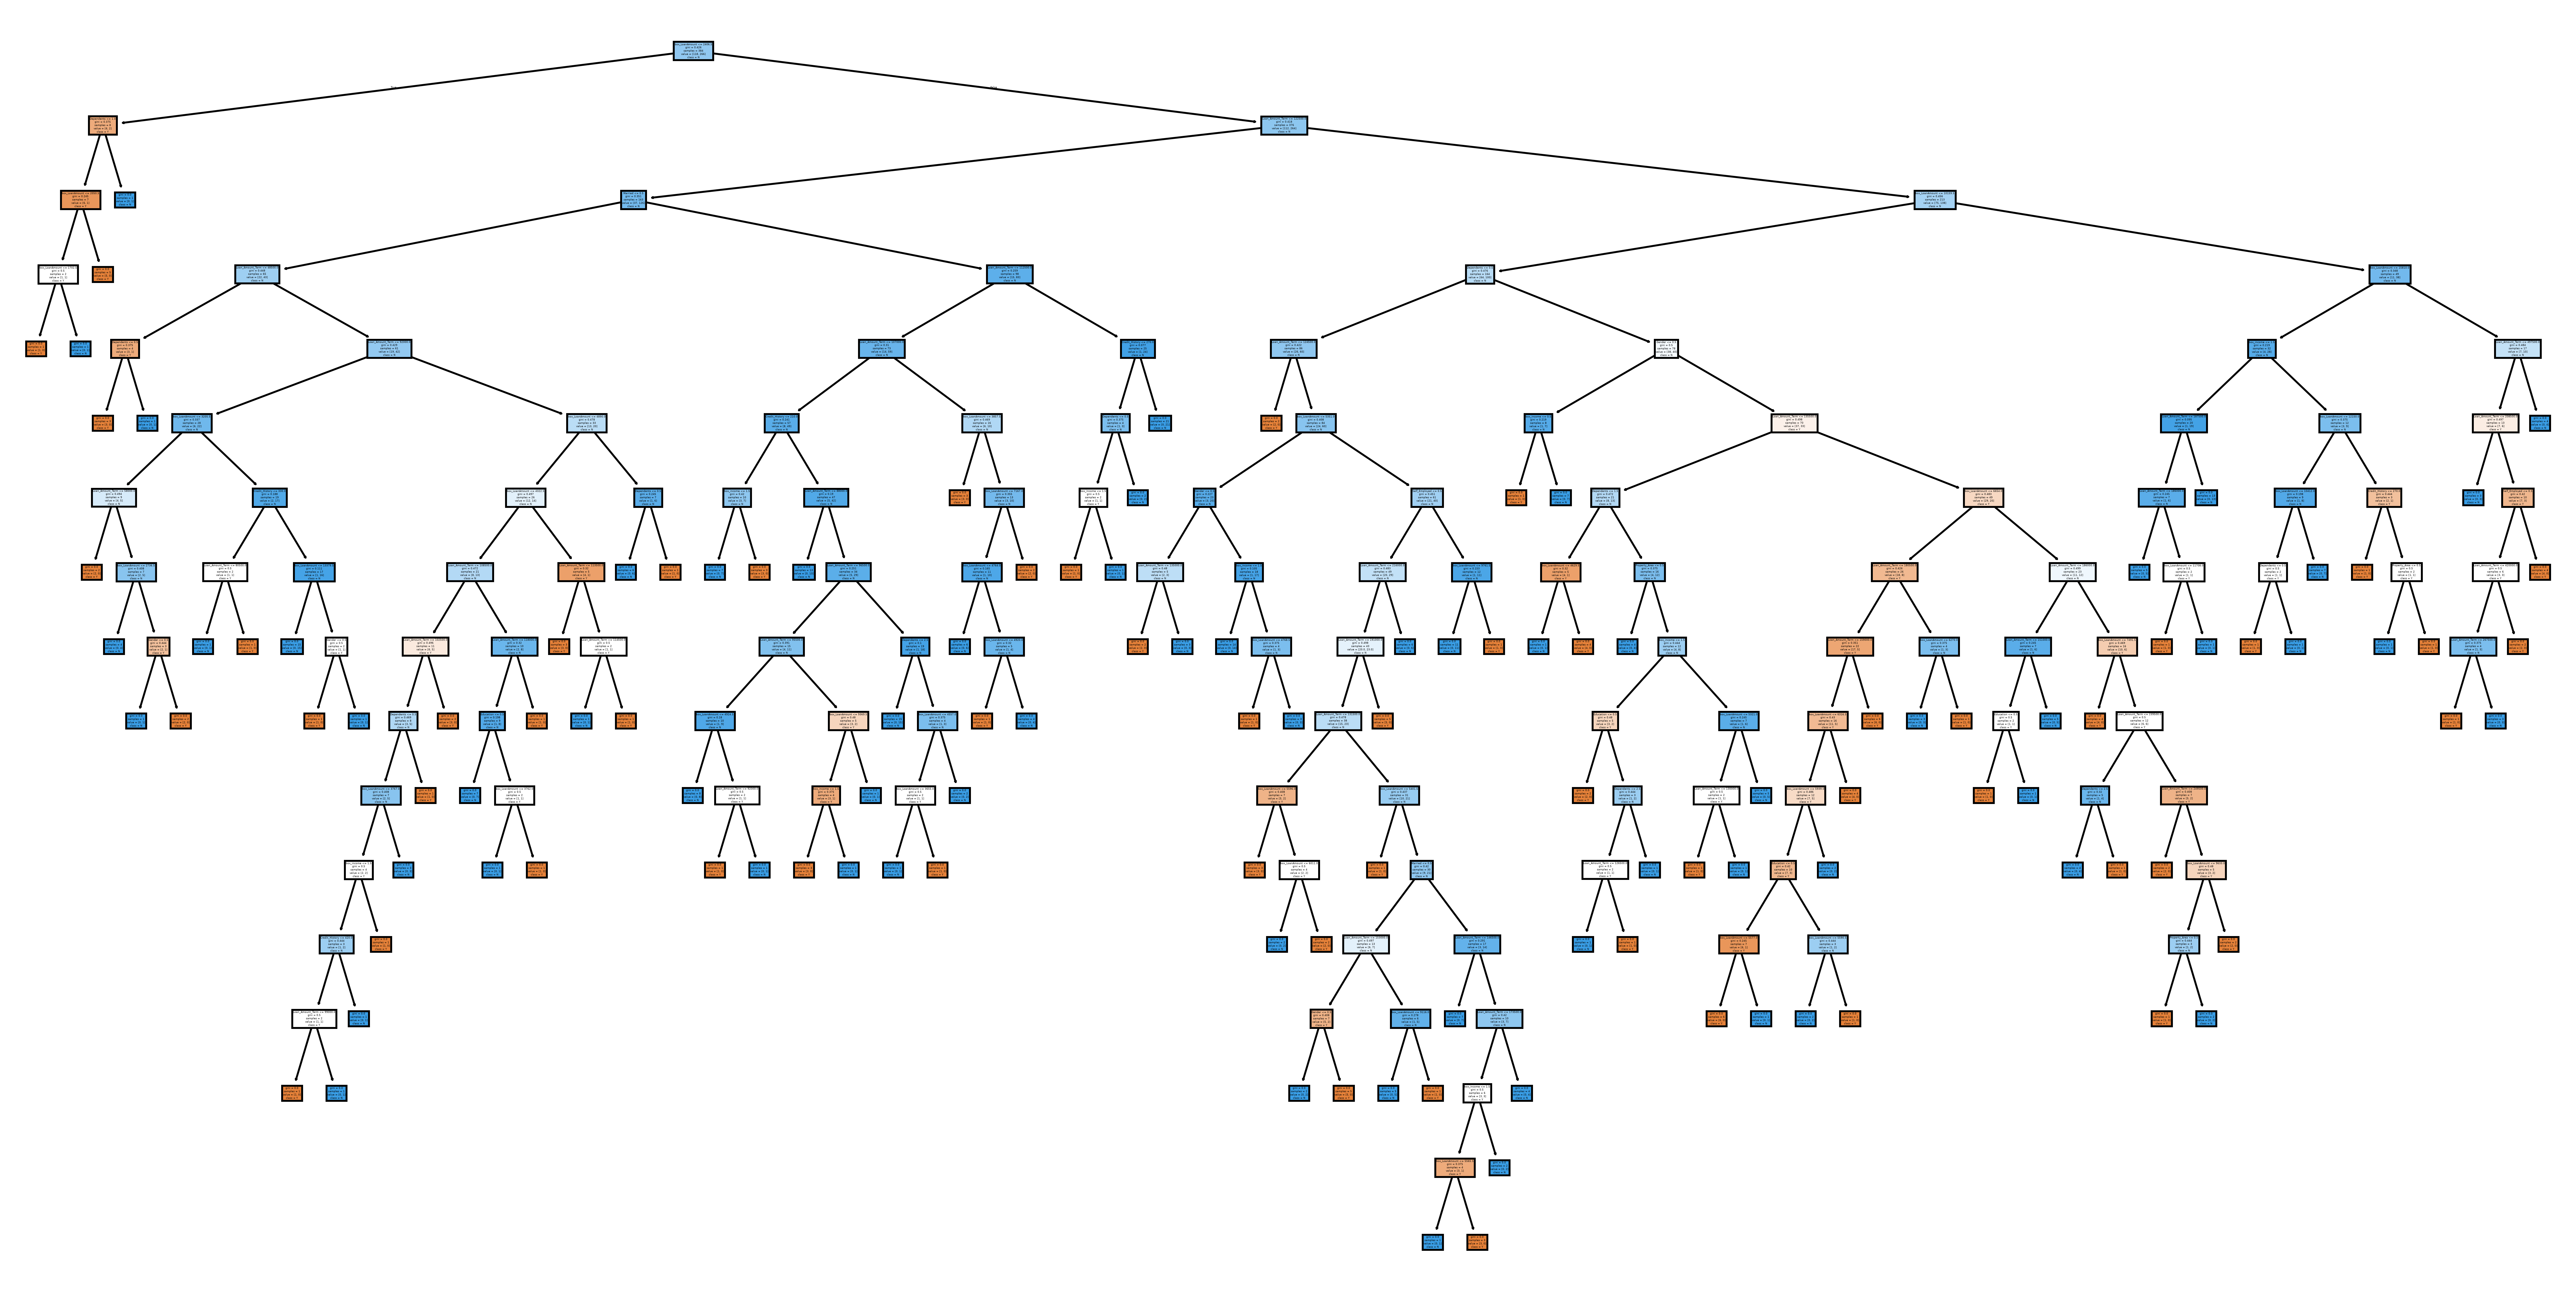

In [168]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(24,12),dpi=500)

plot_tree(dt_base,filled=True,
          feature_names=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'box_income',
       'box_LoanAmount'],class_names=["Y","N"])

plt.show()

In [169]:
x_train

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,income
462,1,1,2,0,1,205000,240,1,1,6000.0
367,1,1,1,1,0,113000,180,0,0,4153.0
179,1,1,1,0,0,104000,360,1,1,4545.0
112,1,1,1,0,0,30000,360,1,2,2963.0
413,1,0,1,1,0,94000,360,1,1,3981.0
...,...,...,...,...,...,...,...,...,...,...
316,1,1,0,1,0,115000,360,1,2,4567.0
280,1,1,2,0,0,236000,360,1,1,8667.0
114,1,1,0,0,0,125000,360,1,1,5690.0
214,1,0,0,0,0,126000,360,1,0,4690.0


In [170]:
dt_base.feature_importances_

array([0.05173517, 0.02375767, 0.08760163, 0.02444853, 0.01978344,
       0.33897436, 0.0146898 , 0.01835096, 0.07844794, 0.3422105 ])

In [171]:
feats = pd.DataFrame(data=np.round(dt_base.feature_importances_*100,2),
                    index=x.columns,
                    columns=["Feature Importance"])
feats.sort_values(by="Feature Importance",ascending=False)

,Feature Importance
income,34.22
LoanAmount,33.90
Dependents,8.76
Property_Area,7.84
Gender,5.17
Education,2.44
Married,2.38
Self_Employed,1.98
Credit_History,1.84
Loan_Amount_Term,1.47


In [172]:
estimator = DecisionTreeClassifier(random_state=70)
param_grid = {"criterion":["gini","entropy"],
              "max_depth":list(range(1,17))}

from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)
grid.fit(x_train,y_train)

grid.best_params_

{'criterion': 'entropy', 'max_depth': 2}

In [173]:
from sklearn.tree import DecisionTreeClassifier
dt_opt = DecisionTreeClassifier(random_state=70,max_depth=1)
dt_opt.fit(x_train,y_train)

y_pred_train = dt_opt.predict(x_train)
y_pred_test = dt_opt.predict(x_test)

print("train_accuracy:",accuracy_score(y_pred_train,y_train))
print("test_accuracy: ",accuracy_score(y_test,y_pred_test))
print(
    "Cross Validation:",
    cross_val_score(
        dt_base,
        x_train,
        y_train,
        cv=5,
        scoring="accuracy"
    ).mean()
)

train_accuracy: 0.703125
test_accuracy:  0.65625
Cross Validation: 0.557347915242652


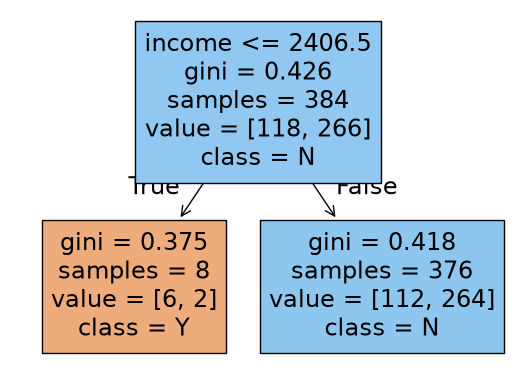

In [174]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


plot_tree(dt_opt,filled=True,
          feature_names= x_train.columns,
          class_names=["Y","N"])

plt.show()

In [175]:
feats = pd.DataFrame(data=np.round(dt_opt.feature_importances_*100,2),
                    index=x.columns,
                    columns=["Feature Importance"])
feats.sort_values(by="Feature Importance",ascending=False)

,Feature Importance
income,100.0
Gender,0.0
Married,0.0
Dependents,0.0
Self_Employed,0.0
Education,0.0
LoanAmount,0.0
Loan_Amount_Term,0.0
Credit_History,0.0
Property_Area,0.0


**Random Forest**

In [176]:
from sklearn.ensemble import RandomForestClassifier

estimator =RandomForestClassifier(random_state=70)

param_grid = {"n_estimators":list(range(20,30))}

grid = GridSearchCV(estimator,param_grid,scoring="accuracy",cv=5)

grid.fit(x_train,y_train)

grid.best_params_

{'n_estimators': 27}

In [177]:
grid.best_estimator_.feature_importances_

array([0.03277599, 0.03282641, 0.08072804, 0.0375616 , 0.02765241,
       0.31835306, 0.03883031, 0.03214627, 0.05762158, 0.34150434])

In [178]:
feats = pd.DataFrame(data=grid.best_estimator_.feature_importances_,
                    index=x_train.columns,
                    columns=["Feature Importacne"])
feats_im = feats[feats["Feature Importacne"]>0]
imp_features = feats_im.index.to_list()
imp_features

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area',
 'income']

In [179]:
x2= x[imp_features] 
x2_train,x2_test,y2_train,y2_test = train_test_split(x2,y,train_size=0.8,random_state=70)

rf = RandomForestClassifier(n_estimators=25,random_state=70)
rf.fit(x2_train,y2_train)

y2_pred_train = rf.predict(x2_train)
print("train_accuracy:",accuracy_score(y2_train,y2_pred_train))

print("cv:",cross_val_score(rf,x2_train,y2_train,cv=5,scoring="accuracy").mean())

y2_pred_test = rf.predict(x2_test)
print("test_accuracy:",accuracy_score(y2_test,y2_pred_test))

train_accuracy: 0.9947916666666666
cv: 0.7812713602187287
test_accuracy: 0.7395833333333334


**AdaBoost**

In [180]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
ab= AdaBoostClassifier()
param_grid_ab = {"n_estimators":list(range(1,100))}

grid_ab = GridSearchCV(ab,param_grid_ab,cv=5,scoring="accuracy")
grid_ab.fit(x_train,y_train)

grid_ab.best_params_

{'n_estimators': 6}

In [181]:
grid_ab.best_estimator_.feature_importances_

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.18286113, 0.16105392, 0.        , 0.        , 0.65608495])

In [182]:
feats = pd.DataFrame(data=grid_ab.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Feature Importacne"])
feats
feats_im = feats[feats["Feature Importacne"]>0]
imp_features = feats_im.index.to_list()
imp_features

['LoanAmount', 'Loan_Amount_Term', 'income']

In [183]:
x3= x[imp_features] 
x3_train,x3_test,y3_train,y3_test = train_test_split(x3,y,train_size=0.8,random_state=70)

ab = AdaBoostClassifier(n_estimators=15,random_state=70)
ab.fit(x3_train,y3_train)

y3_pred_train = ab.predict(x3_train)
print("train_accuracy:",accuracy_score(y3_train,y3_pred_train))

print("cv:",cross_val_score(ab,x3_train,y3_train,cv=5,scoring="accuracy").mean())

y3_pred_test = ab.predict(x3_test)
print("test_accuracy:",accuracy_score(y3_test,y3_pred_test))

train_accuracy: 0.7057291666666666
cv: 0.6719412166780587
test_accuracy: 0.6875


**Gradient Boost**

In [184]:
gb = GradientBoostingClassifier()
param_grid_gb = {"n_estimators":list(range(1,100))}

grid_gb = GridSearchCV(gb,param_grid_gb,cv=5,scoring="accuracy")
grid_gb.fit(x_train,y_train)
grid_gb.best_params_

{'n_estimators': 1}

In [185]:
grid_gb.best_estimator_.feature_importances_

array([0.        , 0.20902003, 0.        , 0.        , 0.        ,
       0.32495588, 0.        , 0.        , 0.        , 0.46602409])

In [186]:
feats_gb = pd.DataFrame(data=grid_gb.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Feature Importacne"])
feats_im = feats_gb[feats_gb["Feature Importacne"]>0]
imp_features = feats_im.index.to_list()
imp_features

['Married', 'LoanAmount', 'income']

In [187]:
x4= x[imp_features] 
x4_train,x4_test,y4_train,y4_test = train_test_split(x4,y,train_size=0.8,random_state=70)

gb = GradientBoostingClassifier(n_estimators=30,learning_rate=0.1)
gb.fit(x4_train,y4_train)

y4_pred_train = gb.predict(x4_train)
print("train_accuracy:",accuracy_score(y4_train,y4_pred_train))

print("cv:",cross_val_score(gb,x4_train,y4_train,cv=5,scoring="accuracy").mean())

y4_pred_test = gb.predict(x4_test)
print("test_accuracy:",accuracy_score(y4_test,y4_pred_test))

train_accuracy: 0.7864583333333334
cv: 0.6979152426520847
test_accuracy: 0.65625


**xgboost classifier**

In [188]:
%pip install xgboost  

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [189]:
from xgboost import XGBClassifier

estimator_xgb = XGBClassifier()

param_grid = {"n_estimators":list(range(1,20))}

grid_xgb = GridSearchCV(estimator_xgb,param_grid,cv=5,scoring="accuracy")
grid_xgb.fit(x_train,y_train)

grid_xgb.best_params_

{'n_estimators': 1}

In [190]:
f_xgb = pd.DataFrame(data=grid_xgb.best_estimator_.feature_importances_,
                    index=x.columns,
                    columns=["Importance"])
imp_features_list_xgb = f_xgb[f_xgb["Importance"]>0].index.to_list()
imp_features_list_xgb

['Gender',
 'Married',
 'Dependents',
 'Self_Employed',
 'LoanAmount',
 'Loan_Amount_Term',
 'Property_Area',
 'income']

In [191]:
x5=x[imp_features_list_xgb]

x5_train,x5_test,y5_train,y5_test = train_test_split(x5,y,train_size=0.8,random_state=70)

xgb=XGBClassifier(n_estimators=10)
xgb.fit(x5_train,y5_train)

y5_pred_train = xgb.predict(x5_train)
print("train_accuracy:",accuracy_score(y5_train,y5_pred_train))

print("cv:",cross_val_score(xgb,x5_train,y5_train,cv=5,scoring="accuracy").mean())

y5_pred_test = xgb.predict(x5_test)
print("test_accuracy:",accuracy_score(y5_test,y5_pred_test))

train_accuracy: 0.8776041666666666
cv: 0.6665755297334245
test_accuracy: 0.6354166666666666


## models selection

- DecisonTreeclassifier was selected as the best model
(maximum test accuracy with less amount of time)

In [192]:
dt_base

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",70
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [193]:
x1= x[imp_features] 
x1_train,x1_test,y1_train,y1_test = train_test_split(x1,y,train_size=0.8,random_state=70)


In [194]:
dt = DecisionTreeClassifier(criterion="gini",max_depth=1,random_state=70)
dt.fit(x1_train,y1_train)

y1_pred_train = dt.predict(x1_train)
print("train_accuracy:",accuracy_score(y1_train,y1_pred_train))
y1_pred_test = dt.predict(x1_test)
print("test_accuracy:",accuracy_score(y1_test,y1_pred_test))
print("cv:",cross_val_score(dt,x1_train,y1_train,cv=5,scoring="accuracy").mean())

train_accuracy: 0.7083333333333334
test_accuracy: 0.6875
cv: 0.6667464114832535


In [195]:
x1

,Married,LoanAmount,income
0,1,128000,6091.0
1,1,66000,3000.0
2,1,120000,4941.0
3,0,141000,6000.0
4,1,267000,9613.0
...,...,...,...
475,0,71000,2900.0
476,1,40000,4106.0
477,1,253000,8312.0
478,1,187000,7583.0


In [196]:
x=df.drop("Loan_Status",axis=1)
y = df["Loan_Status"]

In [197]:
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=70)

In [198]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [199]:
import pandas as pd

df = pd.read_csv("LoanData.csv")

print(df.shape)
print(df.columns)
df.head()

(614, 13)
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [200]:
# Create X and y
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

# Train-test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (491, 12)
x_test: (123, 12)
y_train: (491,)
y_test: (123,)


In [201]:
from sklearn.model_selection import train_test_split

# Remove Loan_ID because it is only an identifier
X = df.drop(columns=["Loan_Status", "Loan_ID"], errors="ignore")
y = df["Loan_Status"]

print("Features:")
print(X.columns.tolist())

Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_cols = x_train.select_dtypes(include=["object"]).columns
numeric_cols = x_train.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numeric_cols)
    ]
)

In [203]:
X = df.drop(columns=["Loan_Status", "Loan_ID"], errors="ignore")
y = df["Loan_Status"]

In [204]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train.shape)
print(x_test.shape)

(491, 11)
(123, 11)


In [205]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_cols = x_train.select_dtypes(include=["object"]).columns
numeric_cols = x_train.select_dtypes(exclude=["object"]).columns

# Categorical preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Numeric preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Combine both
preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_cols),
    ("numeric", numeric_pipeline, numeric_cols)
])

In [206]:
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("svm", SVC())
])

In [207]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "svm__C": [0.1, 1, 10],
    "svm__kernel": ["linear", "rbf"]
}

svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1
)

svm_grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svm', SVC())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'svm__C': [0.1, 1, ...], 'svm__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of infor

In [208]:
from sklearn.metrics import accuracy_score

svm_model = svm_grid.best_estimator_

y_pred_train = svm_model.predict(x_train)
y_pred_test = svm_model.predict(x_test)

print("Best Parameters:", svm_grid.best_params_)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
print("CV Accuracy:", svm_grid.best_score_)

Best Parameters: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Train Accuracy: 0.7983706720977597
Test Accuracy: 0.8536585365853658
CV Accuracy: 0.7983315876103547


In [209]:
X.columns.to_list()

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'Property_Area']

In [210]:
%pip install -U litert

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement litert (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for litert


In [211]:
import pandas as pd

df = pd.read_csv("LoanData.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (614, 13)
Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [212]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [213]:
print(df["Loan_Status"].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [214]:
X = df.drop(columns=["Loan_Status", "Loan_ID"], errors="ignore")
y = df["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", X.columns.tolist())

X shape: (614, 11)
y shape: (614,)
Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [215]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (491, 11)
Testing data: (123, 11)


In [216]:
categorical_cols = x_train.select_dtypes(include=["object"]).columns
numeric_cols = x_train.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", categorical_cols.tolist())
print("Numerical columns:", numeric_cols.tolist())

Categorical columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical columns: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [217]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_cols),
    ("numeric", numeric_pipeline, numeric_cols)
])

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [218]:
from sklearn.neural_network import MLPClassifier

ann_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ann", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=42
    ))
])

print("ANN model created successfully!")

ANN model created successfully!


In [219]:
ann_model.fit(x_train, y_train)

print("ANN training completed successfully!")

y_pred_ann = ann_model.predict(x_test)

print("Prediction completed successfully!")

ANN training completed successfully!
Prediction completed successfully!


In [220]:
from sklearn.metrics import accuracy_score

ann_accuracy = accuracy_score(y_test, y_pred_ann)

print("ANN Accuracy:", ann_accuracy)
print("ANN Accuracy (%):", round(ann_accuracy * 100, 2), "%")

ANN Accuracy: 0.7886178861788617
ANN Accuracy (%): 78.86 %


In [221]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           N       0.68      0.61      0.64        38
           Y       0.83      0.87      0.85        85

    accuracy                           0.79       123
   macro avg       0.75      0.74      0.74       123
weighted avg       0.78      0.79      0.79       123



In [222]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_ann)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[23 15]
 [11 74]]
